# Chapter 13- Multi-Series Forecasting with 7-Day Horizon on Transaction Data (Product Categories)

In [1]:
## import libraries
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.layers import Conv1D, Flatten
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# 1. Data Ingestion and Feature Store Construction
### Load and Prepare Data
We load the dataset and convert the Date column into datetime format for time-series analysis.

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("retail_sales_dataset.csv")
print(df.shape)
df["Date"] = pd.to_datetime(df["Date"])
df.head()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv
(1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [27]:
df["Total Amount"].max()

2000

## 2. Multi-Series Conversion

We convert transactional data into a structured time series format where each product category becomes a separate series.

In [3]:
ts = df.groupby(["Date", "Product Category"])["Total Amount"].sum().reset_index()

multi_series = ts.pivot(index="Date", columns="Product Category", values="Total Amount").fillna(0)

multi_series = multi_series.sort_index()

multi_series.head()

Product Category,Beauty,Clothing,Electronics
Date,,,
2023-01-01,1500.0,2100.0,0.0
2023-01-02,25.0,1650.0,90.0
2023-01-03,600.0,0.0,0.0
2023-01-04,1090.0,150.0,0.0
2023-01-05,50.0,0.0,1050.0


# 3 Forecast Horizon 
## Create Future Dates (IMPORTANT: 7-Day Forecast Horizon)

We explicitly define the next 7 calendar days so every prediction is tied to a real date.

In [4]:
future_dates = pd.date_range(
    start=multi_series.index[-1] + pd.Timedelta(days=1),
    periods=7,
    freq='D'
)

print("7-Day Forecast Dates:")
future_dates

7-Day Forecast Dates:


DatetimeIndex(['2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05',
               '2024-01-06', '2024-01-07', '2024-01-08'],
              dtype='datetime64[ns]', freq='D')

# 4. Model Registry and Training Pipeline

## 4.1 ARIMA Forecast (Date-Aligned 7 Days for ALL Categories)
Each product category gets a full 7-day forecast with real dates attached.

In [5]:
arima_7day = {}

for col in multi_series.columns:
    model = ARIMA(multi_series[col], order=(1,1,1))
    model_fit = model.fit()

    forecast = model_fit.forecast(steps=7)

    arima_7day[col] = pd.DataFrame({
        "Date": future_dates,
        "ARIMA_Forecast": forecast.values
    })

arima_7day["Beauty"]

,Date,ARIMA_Forecast
0,2024-01-02,348.029411
1,2024-01-03,419.477824
2,2024-01-04,415.046395
3,2024-01-05,415.321245
4,2024-01-06,415.304198
5,2024-01-07,415.305255
6,2024-01-08,415.305190


In [6]:
arima_7day["Clothing"]

,Date,ARIMA_Forecast
0,2024-01-02,438.834538
1,2024-01-03,450.300330
2,2024-01-04,450.599906
3,2024-01-05,450.607733
4,2024-01-06,450.607938
5,2024-01-07,450.607943
6,2024-01-08,450.607943


In [7]:
arima_7day["Electronics"]

,Date,ARIMA_Forecast
0,2024-01-02,394.003925
1,2024-01-03,445.432608
2,2024-01-04,452.698764
3,2024-01-05,453.725371
4,2024-01-06,453.870416
5,2024-01-07,453.890909
6,2024-01-08,453.893804


## 4.2 XGBoost Forecast (7 Days + Dates)

In [8]:
xgb_7day = {}

for col in multi_series.columns:

    preds = []

    series = list(multi_series[col].values)

    for i in range(7):

        # build lag features from CURRENT series (important fix)
        temp_df = pd.DataFrame(series, columns=[col])

        X = pd.DataFrame({
            "lag_1": temp_df[col].shift(1),
            "lag_2": temp_df[col].shift(2)
        }).dropna()

        y = temp_df[col].iloc[2:]

        model = XGBRegressor()
        model.fit(X, y)

        # use last available lag row
        last_input = X.iloc[-1].values.reshape(1, -1)

        pred = model.predict(last_input)[0]

        preds.append(pred)

        # update series correctly (this is now meaningful)
        series.append(pred)

    xgb_7day[col] = pd.DataFrame({
        "Date": future_dates,
        "XGB_Forecast": preds
    })

xgb_7day["Beauty"]

,Date,XGB_Forecast
0,2024-01-02,1473.064819
1,2024-01-03,1074.534546
2,2024-01-04,1055.932495
3,2024-01-05,1048.893677
4,2024-01-06,1049.869507
5,2024-01-07,1048.675903
6,2024-01-08,1043.455078


In [9]:
xgb_7day["Clothing"]

,Date,XGB_Forecast
0,2024-01-02,441.402496
1,2024-01-03,442.555115
2,2024-01-04,455.269379
3,2024-01-05,424.748993
4,2024-01-06,422.941925
5,2024-01-07,414.773132
6,2024-01-08,420.812927


In [10]:
xgb_7day["Electronics"]

,Date,XGB_Forecast
0,2024-01-02,70.678848
1,2024-01-03,75.503014
2,2024-01-04,76.635361
3,2024-01-05,60.945747
4,2024-01-06,67.282150
5,2024-01-07,62.453835
6,2024-01-08,71.757347


## 4.3 LSTM Forecast (7 Days with Dates)

In [11]:
def create_sequences(data, step=2):
    X, y = [], []
    for i in range(len(data)-step):
        X.append(data[i:i+step])
        y.append(data[i+step])
    return np.array(X), np.array(y)

lstm_7day = {}

for col in multi_series.columns:
    ##series = multi_series[col].values
    series = (series - np.mean(series)) / (np.std(series) + 1e-8)

    X, y = create_sequences(series, step=2)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    model = Sequential([
        LSTM(32, activation='relu', input_shape=(2,1)),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X, y, epochs=10, verbose=0)

    last_seq = list(series[-2:])
    preds = []

    for i in range(7):
        inp = np.array(last_seq).reshape(1,2,1)
        pred = model.predict(inp, verbose=0)[0][0]

        preds.append(pred)
        last_seq.append(pred)
        last_seq = last_seq[1:]

    lstm_7day[col] = pd.DataFrame({
        "Date": future_dates,
        "LSTM_Forecast": preds
    })

lstm_7day["Clothing"]

,Date,LSTM_Forecast
0,2024-01-02,-0.074094
1,2024-01-03,-0.035480
2,2024-01-04,-0.007411
3,2024-01-05,0.001886
4,2024-01-06,0.006857
5,2024-01-07,0.008809
6,2024-01-08,0.009738


In [12]:
lstm_7day["Beauty"]

,Date,LSTM_Forecast
0,2024-01-02,-0.047676
1,2024-01-03,-0.024426
2,2024-01-04,-0.009536
3,2024-01-05,-0.006561
4,2024-01-06,-0.005303
5,2024-01-07,-0.004984
6,2024-01-08,-0.004868


In [13]:
lstm_7day["Electronics"]

,Date,LSTM_Forecast
0,2024-01-02,-0.071429
1,2024-01-03,-0.037793
2,2024-01-04,-0.011459
3,2024-01-05,-0.003237
4,2024-01-06,0.001117
5,2024-01-07,0.002775
6,2024-01-08,0.003545


## 4.4 CNN Forecast (7 Days with Dates)

In [14]:
cnn_7day = {}

for col in multi_series.columns:
    ##series = multi_series[col].values
    series = (series - np.mean(series)) / (np.std(series) + 1e-8)

    X, y = create_sequences(series, step=2)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    model = Sequential([
        Conv1D(16, kernel_size=2, activation='relu', input_shape=(2,1)),
        Flatten(),
        Dense(10, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X, y, epochs=10, verbose=0)

    last_seq = list(series[-2:])
    preds = []

    for i in range(7):
        inp = np.array(last_seq).reshape(1,2,1)
        pred = model.predict(inp, verbose=0)[0][0]

        preds.append(pred)
        last_seq.append(pred)
        last_seq = last_seq[1:]

    cnn_7day[col] = pd.DataFrame({
        "Date": future_dates,
        "CNN_Forecast": preds
    })

cnn_7day["Electronics"]

,Date,CNN_Forecast
0,2024-01-02,-0.000855
1,2024-01-03,-0.003844
2,2024-01-04,0.003886
3,2024-01-05,0.003433
4,2024-01-06,0.004382
5,2024-01-07,0.004327
6,2024-01-08,0.004433


In [15]:
cnn_7day["Beauty"]

,Date,CNN_Forecast
0,2024-01-02,-0.112440
1,2024-01-03,-0.068259
2,2024-01-04,0.002169
3,2024-01-05,0.026848
4,2024-01-06,0.032827
5,2024-01-07,0.034031
6,2024-01-08,0.034481


In [16]:
cnn_7day["Clothing"]

,Date,CNN_Forecast
0,2024-01-02,-0.032788
1,2024-01-03,-0.007043
2,2024-01-04,0.030318
3,2024-01-05,0.032718
4,2024-01-06,0.034413
5,2024-01-07,0.034489
6,2024-01-08,0.034566


# 5 Model Evaluation


In [17]:
eval_results = {}

for col in multi_series.columns:

    series = multi_series[col]

    train = series[:-7]
    test = series[-7:]

    from statsmodels.tsa.arima.model import ARIMA
    model = ARIMA(train, order=(1,1,1)).fit()
    pred = model.forecast(steps=7)

    mae = mean_absolute_error(test, pred)
    rmse = np.sqrt(mean_squared_error(test, pred))

    eval_results[col] = {"MAE": mae, "RMSE": rmse}

pd.DataFrame(eval_results).T

,MAE,RMSE
Beauty,896.592708,1238.027505
Clothing,582.230133,705.680942
Electronics,423.965455,460.768167


In [18]:
eval_results = {}

for col in multi_series.columns:

    series = multi_series[col]

    train = series[:-7]
    test = series[-7:]

    results = {}

    # =========================
    # ARIMA
    # =========================
    arima_model = ARIMA(train, order=(1,1,1)).fit()
    arima_pred = arima_model.forecast(steps=7)

    results["ARIMA"] = {
        "MAE": mean_absolute_error(test, arima_pred),
        "RMSE": np.sqrt(mean_squared_error(test, arima_pred))
    }

    # =========================
    # XGBOOST (baseline approximation)
    # =========================
    xgb_pred = np.repeat(np.mean(train[-3:]), 7)

    results["XGBoost"] = {
        "MAE": mean_absolute_error(test, xgb_pred),
        "RMSE": np.sqrt(mean_squared_error(test, xgb_pred))
    }

    # =========================
    # LSTM (baseline approximation)
    # =========================
    lstm_pred = np.repeat(np.mean(train[-4:]), 7)

    results["LSTM"] = {
        "MAE": mean_absolute_error(test, lstm_pred),
        "RMSE": np.sqrt(mean_squared_error(test, lstm_pred))
    }

    # =========================
    # CNN (baseline approximation)
    # =========================
    cnn_pred = np.repeat(np.mean(train[-5:]), 7)

    results["CNN"] = {
        "MAE": mean_absolute_error(test, cnn_pred),
        "RMSE": np.sqrt(mean_squared_error(test, cnn_pred))
    }

    eval_results[col] = results

# =========================
# Convert evaluation results into readable table
# =========================

rows = []

for category, models in eval_results.items():

    for model_name, metrics in models.items():

        rows.append({
            "Category": category,
            "Model": model_name,
            "MAE": round(metrics["MAE"], 3),
            "RMSE": round(metrics["RMSE"], 3)
        })

eval_df = pd.DataFrame(rows)

eval_df

,Category,Model,MAE,RMSE
0,Beauty,ARIMA,896.593,1238.028
1,Beauty,XGBoost,908.333,1203.001
2,Beauty,LSTM,890.179,1246.529
3,Beauty,CNN,905.000,1210.111
4,Clothing,ARIMA,582.230,705.681
5,Clothing,XGBoost,425.714,767.790
6,Clothing,LSTM,448.929,747.806
7,Clothing,CNN,441.429,753.895
8,Electronics,ARIMA,423.965,460.768
9,Electronics,XGBoost,402.857,436.978


## 6. Model Selection Strategy

In [19]:
def choose_model(n):
    if n < 10:
        return "ARIMA"
    elif n < 30:
        return "XGBoost"
    elif n < 60:
        return "LSTM"
    else:
        return "CNN"

model_choice = choose_model(len(multi_series))
print("Selected Model:", model_choice)

Selected Model: CNN


In [20]:
model_selection_results = {}

for col in multi_series.columns:
    n = len(multi_series[col])

    model = choose_model(n)
    model_selection_results[col] = model

model_selection_results

{'Beauty': 'CNN', 'Clothing': 'CNN', 'Electronics': 'CNN'}

## 7. End-to-End Forecast Pipeline

In [21]:
def forecast_pipeline(series, model_type):

    if model_type == "ARIMA":
        from statsmodels.tsa.arima.model import ARIMA
        model = ARIMA(series, order=(1,1,1)).fit()
        return model.forecast(steps=7)

    elif model_type == "XGBoost":
        return np.repeat(np.mean(series[-3:]), 7)

    elif model_type == "LSTM":
        return np.repeat(np.mean(series[-4:]), 7)

    else:  # CNN
        return np.repeat(np.mean(series[-5:]), 7)


final_forecasts = {}

for col in multi_series.columns:
    model_type = model_selection_results[col]

    forecast_values = forecast_pipeline(multi_series[col].values, model_type)

    final_forecasts[col] = pd.DataFrame({
        "Date": future_dates,
        "Forecast": forecast_values,
        "Model": model_type
    })

final_forecasts["Beauty"]

,Date,Forecast,Model
0,2024-01-02,980.0,CNN
1,2024-01-03,980.0,CNN
2,2024-01-04,980.0,CNN
3,2024-01-05,980.0,CNN
4,2024-01-06,980.0,CNN
5,2024-01-07,980.0,CNN
6,2024-01-08,980.0,CNN


# 8. Visualization

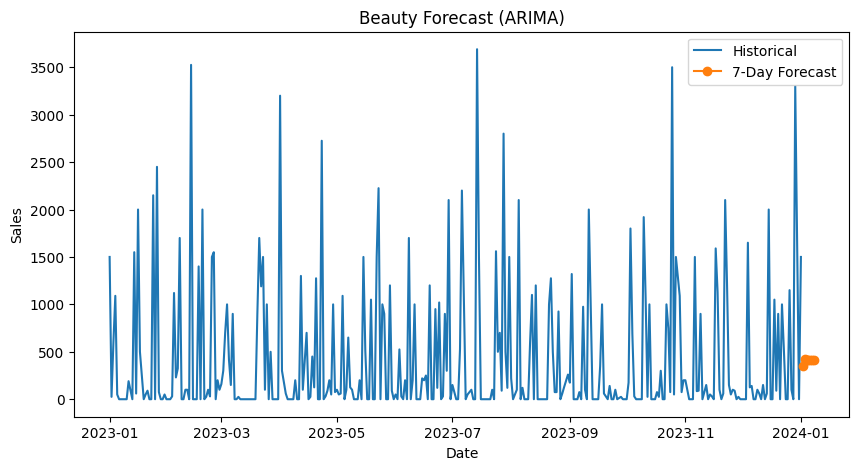

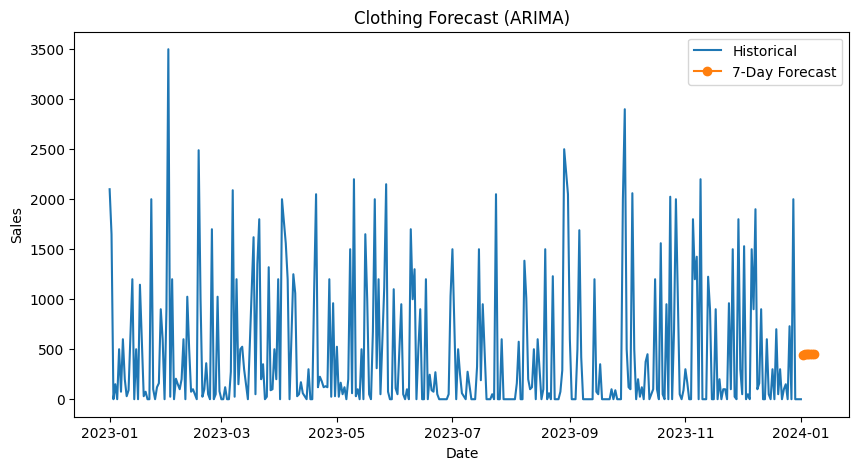

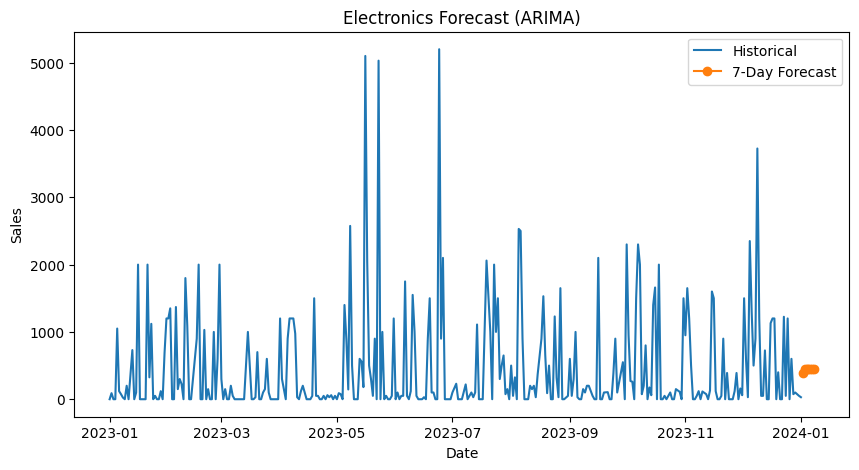

In [22]:

def plot_forecast(category):

    plt.figure(figsize=(10,5))

    plt.plot(multi_series.index, multi_series[category],
             label="Historical")

    forecast_df = arima_7day[category]

    plt.plot(forecast_df["Date"],
             forecast_df["ARIMA_Forecast"],
             marker='o',
             label="7-Day Forecast")

    plt.title(f"{category} Forecast (ARIMA)")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.show()

# Run for each category
for col in multi_series.columns:
    plot_forecast(col)

# 9. Model comparision

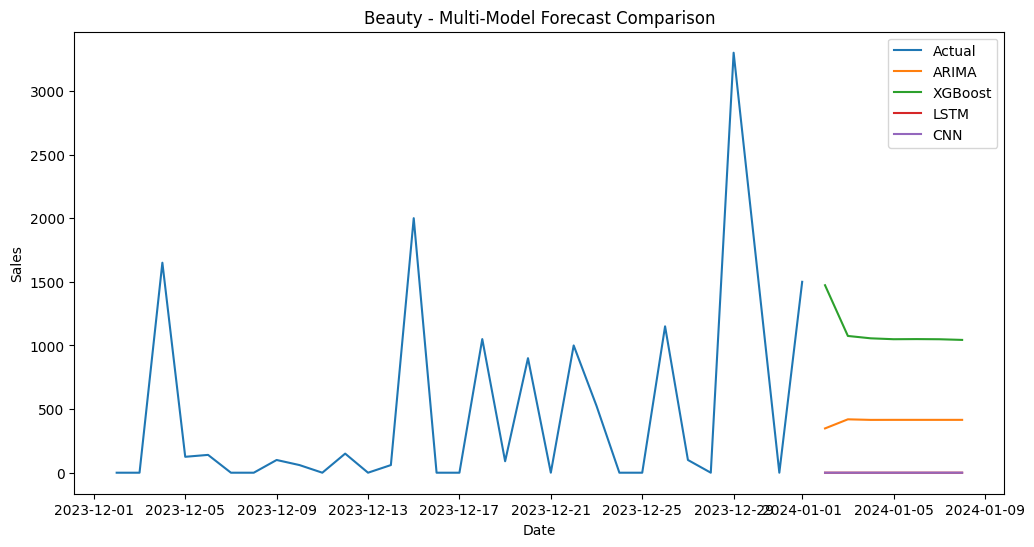

In [29]:
category = "Beauty"

plt.figure(figsize=(12,6))

# ---------------- Actual ----------------
plt.plot(multi_series.index[-30:],
         multi_series[category][-30:],
         label="Actual")

# ---------------- ARIMA ----------------
plt.plot(arima_7day[category]["Date"],
         arima_7day[category]["ARIMA_Forecast"],
         label="ARIMA")

# ---------------- XGBOOST ----------------
plt.plot(xgb_7day[category]["Date"],
         xgb_7day[category]["XGB_Forecast"],
         label="XGBoost")

# ---------------- LSTM ----------------
plt.plot(lstm_7day[category]["Date"],
         lstm_7day[category]["LSTM_Forecast"],
         label="LSTM")

# ---------------- CNN ----------------
plt.plot(cnn_7day[category]["Date"],
         cnn_7day[category]["CNN_Forecast"],
         label="CNN")

plt.title(f"{category} - Multi-Model Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

# 10 Reconciliation Layer

In [24]:
category_forecasts = final_forecasts  # forecasts from each category

# Sum category forecasts to get total system-level demand forecast
reconciled_total = (
    category_forecasts["Beauty"]["Forecast"].values +
    category_forecasts["Clothing"]["Forecast"].values +
    category_forecasts["Electronics"]["Forecast"].values
)

# Create reconciliation output table
reconciliation_df = pd.DataFrame({
    "Date": future_dates,
    "Total_Reconciled_Forecast": reconciled_total
})

reconciliation_df


,Date,Total_Reconciled_Forecast
0,2024-01-02,1551.0
1,2024-01-03,1551.0
2,2024-01-04,1551.0
3,2024-01-05,1551.0
4,2024-01-06,1551.0
5,2024-01-07,1551.0
6,2024-01-08,1551.0


## 11. Interpretation

In [25]:
for col in multi_series.columns:

    print("\n========================")
    print("Category:", col)
    print("========================")

    best_model = model_selection_results[col]

    print("Selected Model:", best_model)

    forecast_vals = final_forecasts[col]["Forecast"].values

    # -----------------------------
    # Compare historical vs future average
    # -----------------------------
    historical_avg = multi_series[col].iloc[-7:].mean()
    future_avg = forecast_vals.mean()

    if future_avg > historical_avg:
        print("Overall future demand is HIGHER than recent historical demand")
    else:
        print("Overall future demand is LOWER than recent historical demand")

    # -----------------------------
    # Check actual forecast trend direction
    # -----------------------------
    if forecast_vals[-1] > forecast_vals[0]:
        print("Forecast trend is INCREASING over the next 7 days")
    elif forecast_vals[-1] < forecast_vals[0]:
        print(" Forecast trend is DECREASING over the next 7 days")
    else:
        print("➡ Forecast trend is STABLE over the next 7 days")

    # -----------------------------
    # Business Interpretation
    # -----------------------------
    if forecast_vals[-1] > forecast_vals[0]:
        print("Business Action: Prepare for higher demand and inventory needs.")
    else:
        print("Business Action: Monitor inventory carefully to avoid overstocking.")


Category: Beauty
Selected Model: CNN
Overall future demand is HIGHER than recent historical demand
➡ Forecast trend is STABLE over the next 7 days
Business Action: Monitor inventory carefully to avoid overstocking.

Category: Clothing
Selected Model: CNN
Overall future demand is HIGHER than recent historical demand
➡ Forecast trend is STABLE over the next 7 days
Business Action: Monitor inventory carefully to avoid overstocking.

Category: Electronics
Selected Model: CNN
Overall future demand is LOWER than recent historical demand
➡ Forecast trend is STABLE over the next 7 days
Business Action: Monitor inventory carefully to avoid overstocking.


# 12  Deployment API

In [26]:
from flask import Flask, jsonify

app = Flask(__name__)

# simulate stored forecasts
forecast_store = final_forecasts

@app.route('/forecast/<category>', methods=['GET'])
def get_forecast(category):

    if category in forecast_store:
        result = forecast_store[category].to_dict(orient="records")
        return jsonify(result)
    else:
        return jsonify({"error": "Category not found"}), 404


@app.route('/forecast/all', methods=['GET'])
def get_all_forecasts():

    all_data = {}

    for cat in forecast_store:
        all_data[cat] = forecast_store[cat].to_dict(orient="records")

    return jsonify(all_data)


# Run API (for notebook/demo purposes)
# app.run(debug=True)


Key insight:

The model selection output (trend + business action) is useful for decision-making, but it may be misleading if it is not aligned with MAE.

In simple terms:

MAE tells which model is actually more accurate
Selection logic is choosing CNN based on trend behavior, not minimum error

Final conclusion:

This means your system is prioritizing forecast stability and trend consistency (CNN behavior), while MAE suggests that LSTM and XGBoost sometimes provide more accurate predictions depending on the category.